In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json


In [2]:
total = 0
skip = 0
lis = []
limit = 100
skip = 0
page = 0
while True:
  request = requests.get(f'https://dummyjson.com/users?limit={limit}&skip={skip}')
  data = request.json()['users']
  dfs = pd.DataFrame(data)
  lis.append(dfs)
  skip += limit
  total = request.json()['total']
  print(page)
  if skip >= total:
    skip = total
    break

  page += 1

df = pd.concat(lis)

0
1
2


In [3]:
df.isna().sum().sum()

np.int64(0)

In [4]:
df['country'] = df['address'].apply(lambda x: x['country'])

In [5]:
df['city'] = df['address'].apply(lambda x: x['city'])

In [6]:
df['city'].value_counts()

,count
city,
Phoenix,17
Dallas,15
Jacksonville,14
Los Angeles,14
Seattle,12
Philadelphia,11
Charlotte,11
San Jose,11
Chicago,11


In [7]:
df['country'].value_counts()

,count
country,
United States,208


In [8]:
df.shape

(208, 30)

In [9]:
df.columns

Index(['id', 'firstName', 'lastName', 'maidenName', 'age', 'gender', 'email',
       'phone', 'username', 'password', 'birthDate', 'image', 'bloodGroup',
       'height', 'weight', 'eyeColor', 'hair', 'ip', 'address', 'macAddress',
       'university', 'bank', 'company', 'ein', 'ssn', 'userAgent', 'crypto',
       'role', 'country', 'city'],
      dtype='object')

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.drop(columns=['id','username','country','birthDate','image','hair','ip','firstName','lastName','maidenName','email','phone','password','macAddress','address','bank','ein','ssn','userAgent','crypto','company'], inplace=True)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.head()

,age,gender,bloodGroup,height,weight,eyeColor,university,role,city
0,29,female,O-,193.24,63.16,Green,University of Wisconsin--Madison,admin,Phoenix
1,36,male,B+,186.22,76.32,Red,Ohio State University,admin,Houston
2,43,female,O-,177.72,52.60,Hazel,Pepperdine University,admin,Washington
3,46,male,AB+,193.31,62.10,Amber,University of Southern California,admin,Seattle
4,31,female,AB-,192.80,63.62,Green,Northeastern University,admin,Jacksonville


In [14]:
df['bloodGroup'].value_counts()

,count
bloodGroup,
O-,31
B-,31
AB-,29
AB+,29
B+,25
O+,22
A+,21
A-,20


In [15]:
df['gender'].value_counts()

,count
gender,
female,106
male,102


In [16]:
df['eyeColor'].value_counts()

,count
eyeColor,
Brown,35
Hazel,34
Green,28
Blue,24
Gray,24
Violet,22
Red,21
Amber,20


In [17]:
df.dtypes

,0
age,int64
gender,object
bloodGroup,object
height,float64
weight,float64
eyeColor,object
university,object
role,object
city,object


In [18]:
df[['gender','bloodGroup','eyeColor','university','role','city']] = df[['gender','bloodGroup','eyeColor','university','role','city']].astype(str)

In [19]:
df.dtypes

,0
age,int64
gender,object
bloodGroup,object
height,float64
weight,float64
eyeColor,object
university,object
role,object
city,object


In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.describe()

,age,height,weight
count,208.000000,208.000000,208.000000
mean,33.139423,175.720240,75.038606
std,5.544269,14.119984,14.090775
min,23.000000,150.250000,50.100000
25%,29.000000,164.187500,62.547500
50%,32.000000,177.430000,75.985000
75%,36.000000,186.960000,86.992500
max,46.000000,199.810000,99.540000


In [22]:
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)
sns.set_palette("viridis")


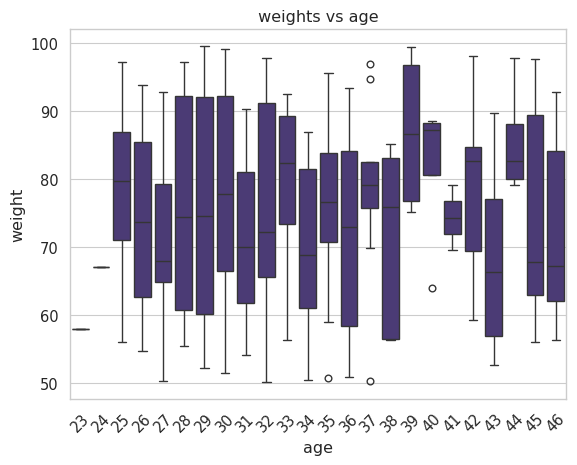

In [23]:
sns.boxplot(data=df,
            x="age",
            y="weight")
plt.title(" weights vs age ")
plt.xlabel("age")
plt.ylabel("weight")
plt.xticks(rotation=45)
plt.show()

In [27]:
df

,age,gender,bloodGroup,height,weight,eyeColor,university,role,city
0,29,female,O-,193.24,63.16,Green,University of Wisconsin--Madison,admin,Phoenix
1,36,male,B+,186.22,76.32,Red,Ohio State University,admin,Houston
2,43,female,O-,177.72,52.60,Hazel,Pepperdine University,admin,Washington
3,46,male,AB+,193.31,62.10,Amber,University of Southern California,admin,Seattle
4,31,female,AB-,192.80,63.62,Green,Northeastern University,admin,Jacksonville
...,...,...,...,...,...,...,...,...,...
3,46,male,AB-,172.33,56.27,Brown,University of Florida,user,Jacksonville
4,29,female,AB+,192.28,85.89,Brown,Pepperdine University,user,Los Angeles
5,35,female,O+,150.62,95.55,Brown,Tufts University,user,San Francisco
6,42,male,A+,185.55,59.24,Gray,University of Rochester,user,Seattle


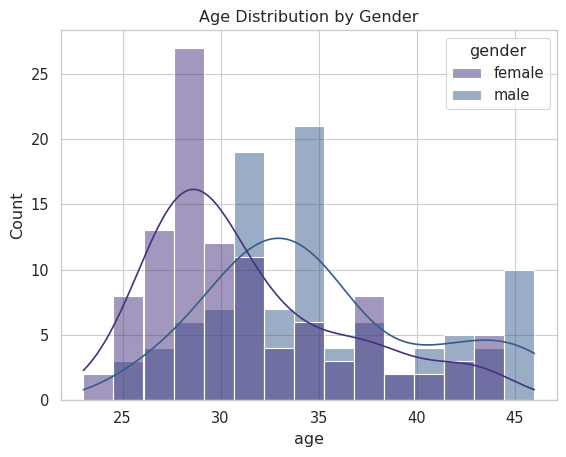

In [38]:
plt.figure()
sns.histplot(data=df, x="age", hue="gender", bins=15, kde=True)
plt.title("Age Distribution by Gender")
plt.savefig("age_distribution.png", bbox_inches="tight")


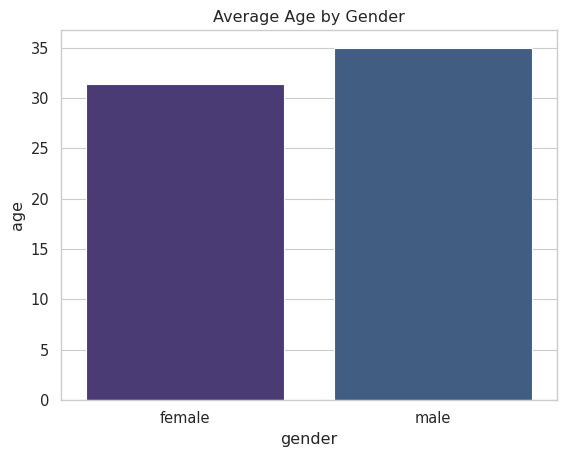

In [37]:
plt.figure()
sns.barplot(data=df, x="gender", y="age", hue="gender", errorbar=None)
plt.title("Average Age by Gender")
plt.savefig("avg_age_by_gender.png", bbox_inches="tight")

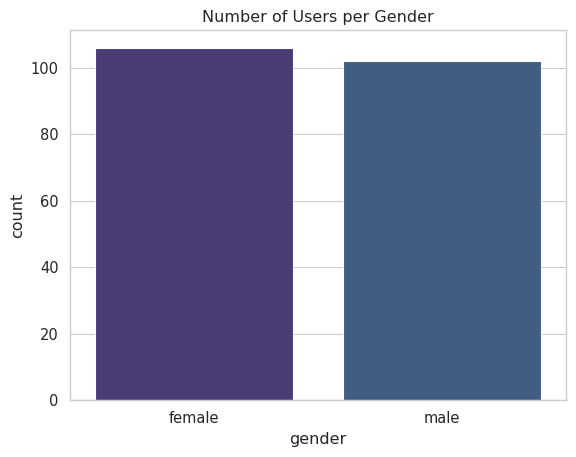

In [36]:
plt.figure()
sns.countplot(data=df, x="gender", hue="gender")
plt.title("Number of Users per Gender")
plt.savefig("users_per_gender.png", bbox_inches="tight")

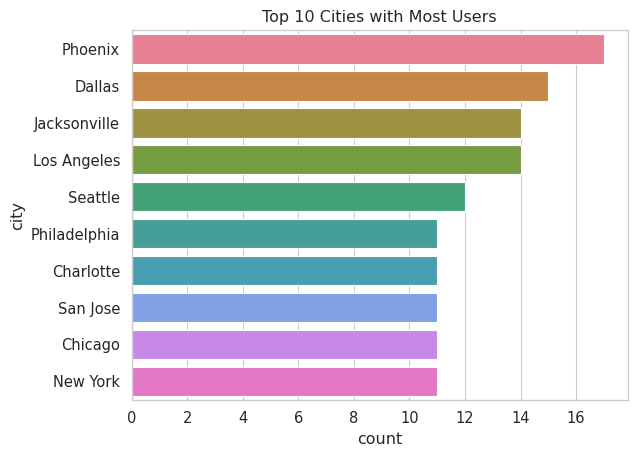

In [35]:
top10 = df["city"].value_counts().head(10).reset_index()
top10.columns = ["city", "count"]
plt.figure()
sns.barplot(data=top10, y="city", x="count", hue="city", legend=False)
plt.title("Top 10 Cities with Most Users")
plt.savefig("top10_cities.png", bbox_inches="tight")

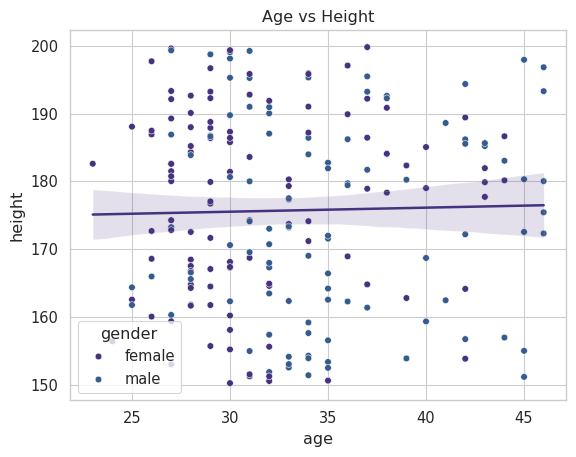

In [34]:
plt.figure()
sns.scatterplot(data=df, x="age", y="height", hue="gender")
sns.regplot(data=df, x="age", y="height", scatter=False)
plt.title("Age vs Height")
plt.savefig("age_vs_height.png", bbox_inches="tight")

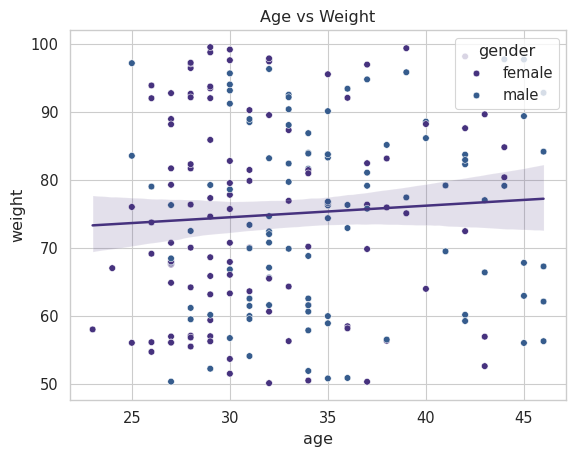

In [40]:
plt.figure()
sns.scatterplot(data=df, x="age", y="weight", hue="gender")
sns.regplot(data=df, x="age", y="weight", scatter=False)
plt.title("Age vs Weight")
plt.savefig("06_age_vs_weight.png", bbox_inches="tight")